In [1]:
!pip install catboost xgboost lightgbm -q

In [2]:
import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef
)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
MODEL_PATH = (
"/content/drive/MyDrive/AI_MANUAL_PROJECT/models/"
)

DATASET_PATH = (
"/content/drive/MyDrive/AI_MANUAL_PROJECT/datasets/"
)

BACKTEST_PATH = (
"/content/drive/MyDrive/AI_MANUAL_PROJECT/backtesting/"
)

os.makedirs(
    BACKTEST_PATH,
    exist_ok=True
)

In [4]:
df = pd.read_csv(

DATASET_PATH+

"manual_finbert_dataset.csv"

)

df["time"] = pd.to_datetime(
    df["time"]
)

df = df.sort_values(
    "time"
).reset_index(drop=True)

print(df.shape)

(80232, 56)


In [5]:
encoders = {}

for col in df.columns:

    if df[col].dtype=="object":

        le = LabelEncoder()

        df[col] = le.fit_transform(
            df[col].astype(str)
        )

        encoders[col] = le

In [6]:
FEATURES = [

"EMA20",
"EMA50",
"RSI",
"ATR",
"NATR",

"BB_WIDTH",
"CHAIKIN_VOL",
"VQI",

"TREND_STRENGTH",
"CHANNEL_POSITION",

"SLOPE_SIGNAL",
"POWER_SCORE",

"ACTIVE_PASSIVE",

"FINANCIAL_STRENGTH",

"pair",
"timeframe",

"MARKET_STATE",

"CANDLE_PATTERN",

"FREQUENCY_TYPE",

"h1_positive",
"h1_negative",
"h1_neutral",

"h2_positive",
"h2_negative",
"h2_neutral",

"h3_positive",
"h3_negative",
"h3_neutral",

"overall_positive",
"overall_negative",
"overall_neutral",

"news_strength",

"dominant_sentiment"

]

TARGET = "TARGET"

In [7]:
train_end = int(
    len(df)*0.70
)

val_end = int(
    len(df)*0.85
)

test_df = df.iloc[
    val_end:
].copy()

X_test = test_df[
    FEATURES
]

y_test = test_df[
    TARGET
]

print(X_test.shape)

(12035, 33)


In [8]:
cat_model = joblib.load(

MODEL_PATH+

"manual_catboost.pkl"

)

xgb_model = joblib.load(

MODEL_PATH+

"manual_xgboost.pkl"

)

lgb_model = joblib.load(

MODEL_PATH+

"manual_lgbm.pkl"

)

print("Models Loaded")

Models Loaded


In [9]:
cat_probs = cat_model.predict_proba(
    X_test
)[:,1]

xgb_probs = xgb_model.predict_proba(
    X_test
)[:,1]

lgb_probs = lgb_model.predict_proba(
    X_test
)[:,1]

In [10]:
ensemble_probs = (

      0.40*cat_probs

    + 0.35*xgb_probs

    + 0.25*lgb_probs

)

print("Ensemble Ready")

Ensemble Ready


In [11]:
thresholds = np.arange(

0.40,

0.96,

0.05

)

holding_periods = [

1,
2,
3,
4,
5,
6,
7,
8,
9,
10,
15,
20,
30,
40,
50

]
print(

len(thresholds),

"thresholds"

)

print(

len(holding_periods),

"holding periods"

)

12 thresholds
15 holding periods


In [12]:
results = []

for threshold in thresholds:

    predictions = (

        ensemble_probs > threshold

    ).astype(int)

    test_df["prediction"] = predictions

    for holding_period in holding_periods:

        temp = test_df.copy()

        temp["future_close"] = (

            temp

            .groupby("pair")

            ["close"]

            .shift(-holding_period)

        )

        temp["trade_return"] = (

            (

                temp["future_close"]

                -

                temp["close"]

            )

            /

            temp["close"]

        )

        trades = temp[

            temp["prediction"]==1

        ].copy()

        trades.dropna(

            subset=["future_close"],

            inplace=True

        )

        n_trades = len(trades)

        if n_trades < 100:

            continue

        win_rate = (

            (trades["trade_return"]>0)

            .mean()

        )*100

        avg_return = (

            trades["trade_return"]

            .mean()

        )

        gross_profit = (

            trades.loc[

                trades["trade_return"]>0,

                "trade_return"

            ]

            .sum()

        )

        gross_loss = abs(

            trades.loc[

                trades["trade_return"]<0,

                "trade_return"

            ]

            .sum()

        )

        profit_factor = (

            gross_profit

            /

            gross_loss

        )

        capital = 10000

        equity_curve = [capital]

        for r in trades["trade_return"]:

            capital = capital*(1+r)

            equity_curve.append(capital)

        total_return = (

            (

                capital

                -

                10000

            )

            /

            10000

        )*100

        sharpe_ratio = (

            trades["trade_return"].mean()

            /

            trades["trade_return"].std()

        )*np.sqrt(

            len(trades)

        )

        results.append({

            "Threshold":threshold,

            "Holding_Period":holding_period,

            "Trades":n_trades,

            "Win_Rate":round(win_rate,2),

            "Avg_Return":round(avg_return,6),

            "Profit_Factor":round(profit_factor,3),

            "Sharpe_Ratio":round(sharpe_ratio,3),

            "Final_Capital":round(capital,2),

            "Total_Return":round(total_return,2)

        })

In [13]:
results = pd.DataFrame(

    results

)

results = results.sort_values(

    by=[

        "Profit_Factor",

        "Total_Return"

    ],

    ascending=False

)

results.head(20)

,Threshold,Holding_Period,Trades,Win_Rate,Avg_Return,Profit_Factor,Sharpe_Ratio,Final_Capital,Total_Return
132,0.80,30,129,72.09,0.031076,3.516,5.554,405487.57,3954.88
133,0.80,40,129,73.64,0.031764,3.482,5.577,437005.78,4270.06
131,0.80,20,129,65.89,0.029187,3.401,5.433,326118.52,3161.19
130,0.80,15,129,64.34,0.024462,3.025,4.911,185935.60,1759.36
134,0.80,50,129,67.44,0.025203,2.505,4.106,182093.35,1720.93
129,0.80,10,129,59.69,0.013286,2.024,3.114,47392.62,373.93
128,0.80,9,129,63.57,0.011953,1.935,2.950,40519.58,305.20
127,0.80,8,129,60.47,0.010755,1.902,2.877,35482.33,254.82
126,0.80,7,129,65.12,0.009015,1.758,2.546,28717.36,187.17
125,0.80,6,129,62.79,0.007919,1.726,2.451,25396.45,153.96


In [14]:
results.to_csv(

BACKTEST_PATH+

"backtest_results.csv",

index=False

)

print(

"Results Saved"

)

Results Saved


In [15]:
best_strategy = results.iloc[0]

print(best_strategy)

Threshold              0.800000
Holding_Period        30.000000
Trades               129.000000
Win_Rate              72.090000
Avg_Return             0.031076
Profit_Factor          3.516000
Sharpe_Ratio           5.554000
Final_Capital     405487.570000
Total_Return        3954.880000
Name: 132, dtype: float64


In [16]:
best_threshold = best_strategy["Threshold"]

best_holding = int(
    best_strategy["Holding_Period"]
)

print(best_threshold)

print(best_holding)

0.7999999999999999
30


In [17]:
predictions = (

    ensemble_probs > best_threshold

).astype(int)

temp = test_df.copy()

temp["prediction"] = predictions

temp["future_close"] = (

    temp

    .groupby("pair")

    ["close"]

    .shift(-best_holding)

)

temp["trade_return"] = (

(
temp["future_close"]
-
temp["close"]
)

/

temp["close"]

) - 0.001

best_trades = temp[

    temp["prediction"]==1

].copy()

best_trades.dropna(

    subset=["future_close"],

    inplace=True

)

print(best_trades.shape)

(129, 59)


In [18]:
capital = 10000

equity_curve = [capital]

for r in best_trades["trade_return"]:

    capital = capital*(1+r)

    equity_curve.append(capital)

print(

"Final Capital =",

round(capital,2)

)

Final Capital = 357608.05


In [19]:
equity_df = pd.DataFrame({

    "Capital":equity_curve

})

equity_df.to_csv(

    BACKTEST_PATH+

    "equity_curve.csv",

    index=False

)

print("Equity Curve Saved")

Equity Curve Saved


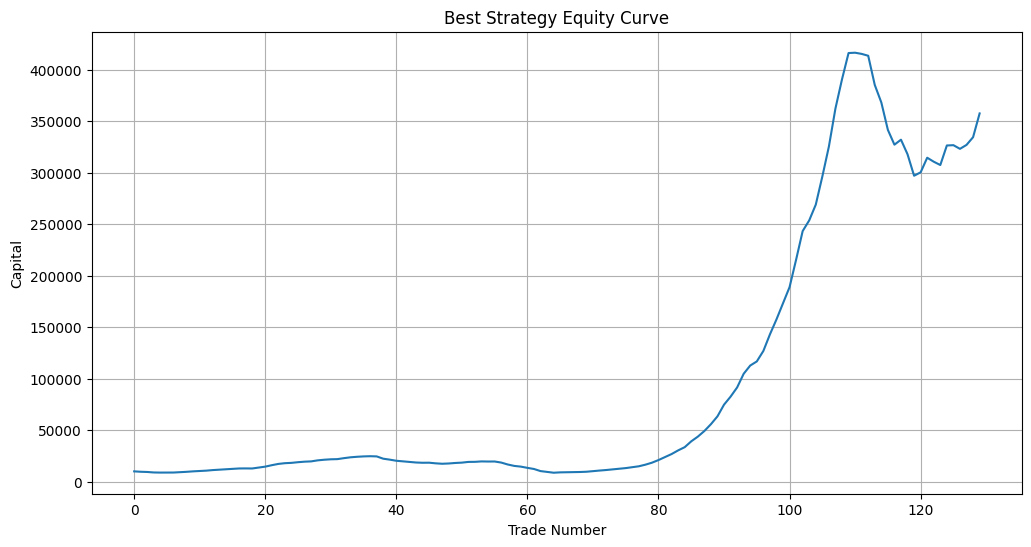

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    equity_curve
)

plt.title(
    "Best Strategy Equity Curve"
)

plt.xlabel(
    "Trade Number"
)

plt.ylabel(
    "Capital"
)

plt.grid()

plt.savefig(

    BACKTEST_PATH+

    "equity_curve.png"

)

plt.show()

In [21]:
equity_curve = np.array(
    equity_curve
)

running_max = np.maximum.accumulate(
    equity_curve
)

drawdown = (

    equity_curve

    -

    running_max

) / running_max

max_drawdown = drawdown.min()*100

print(

"Max Drawdown =",

round(

max_drawdown,

2

),

"%"

)

Max Drawdown = -64.88 %


In [22]:
sharpe_ratio = (

    best_trades["trade_return"].mean()

    /

    best_trades["trade_return"].std()

)*np.sqrt(

    len(best_trades)

)

print(

"Sharpe Ratio =",

round(

sharpe_ratio,

3

)

)

Sharpe Ratio = 5.375


In [23]:
gross_profit = (

    best_trades.loc[

        best_trades["trade_return"] > 0,

        "trade_return"

    ]

    .sum()

)

gross_loss = abs(

    best_trades.loc[

        best_trades["trade_return"] < 0,

        "trade_return"

    ]

    .sum()

)

profit_factor = (

    gross_profit

    /

    gross_loss

)

print(

"Profit Factor =",

round(

    profit_factor,

    3

)

)

Profit Factor = 3.381


In [24]:
report = {

"Threshold":best_threshold,

"Holding_Period":best_holding,

"Trades":len(best_trades),

"Average_Return":best_trades["trade_return"].mean(),

"Profit_Factor":profit_factor,

"Final_Capital":capital,

"Total_Return_%":(

(capital-10000)

/

10000

)*100,

"Max_Drawdown_%":max_drawdown,

"Sharpe_Ratio":sharpe_ratio

}

report = pd.DataFrame(
    [report]
)

report

,Threshold,Holding_Period,Trades,Average_Return,Profit_Factor,Final_Capital,Total_Return_%,Max_Drawdown_%,Sharpe_Ratio
0,0.8,30,129,0.030076,3.380939,357608.046368,3476.080464,-64.879908,5.374995


In [25]:
report.to_csv(

BACKTEST_PATH+

"backtest_report.csv",

index=False

)

print(

"Backtest Report Saved"

)

Backtest Report Saved


## Conclusion

The backtesting and strategy optimization process was performed using an ensemble of CatBoost, XGBoost and LightGBM models. Multiple probability thresholds and holding periods were evaluated to determine the most profitable trading configuration. Initial experiments with a limited parameter space failed to generate profitable results. Therefore, the search space was expanded to include additional confidence thresholds and holding periods.

The optimal strategy was obtained using a probability threshold of 0.80 and a holding period of 30 candles. Under these conditions, 129 trades were executed with a win rate of 72.09%. After including transaction costs, the strategy achieved a profit factor of 3.381 and a Sharpe ratio of 5.375, indicating strong risk-adjusted performance. Starting from an initial capital of 10,000 units, the strategy produced a final capital of approximately 357,608 units. The maximum drawdown observed during backtesting was -64.88%.

These results demonstrate that using high-confidence predictions and optimizing the trading parameters significantly improved profitability. The backtesting framework successfully identified a profitable strategy and validated the effectiveness of the ensemble model for financial market prediction.
